In [4]:
print('Radha!')

Radha!


In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from ipynb.fs.full.Child_Graph import ticket_analysis_graph  # Importing child graph

In [6]:
class SupportState(TypedDict):
    question: str
    category: str
    priority: str
    summary: str
    response: str

In [7]:
def ticket_analysis(state: SupportState):

    result = ticket_analysis_graph.invoke({
        "question": state["question"],
        "category": "",
        "priority": "",
        "summary": ""
    })

    return {
        "category": result["category"],
        "priority": result["priority"],
        "summary": result["summary"]
    }

In [8]:
def generate_response(state: SupportState):

    return {
        "response": (
            f"Thanks for contacting us. "
            f"Your issue is classified as "
            f"{state['category']} with "
            f"{state['priority']} priority."
        )
    }

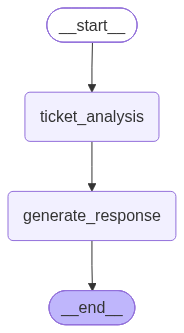

In [9]:
support_builder = StateGraph(SupportState)

support_builder.add_node(
    "ticket_analysis",
    ticket_analysis
)

support_builder.add_node(
    "generate_response",
    generate_response
)

support_builder.add_edge(
    START,
    "ticket_analysis"
)

support_builder.add_edge(
    "ticket_analysis",
    "generate_response"
)

support_builder.add_edge(
    "generate_response",
    END
)

support_graph = support_builder.compile()
support_graph

In [10]:
result = support_graph.invoke({
    "question": "Urgent! I can't access my account.",
    "category": "",
    "priority": "",
    "summary": "",
    "response": ""
})

print(result)

{'question': "Urgent! I can't access my account.", 'category': 'general', 'priority': 'high', 'summary': 'Category: general, Priority: high', 'response': 'Thanks for contacting us. Your issue is classified as general with high priority.'}


In [11]:
result['question']

"Urgent! I can't access my account."

In [12]:
result['category']

'general'

In [13]:
result['priority']

'high'

In [14]:
result['summary']

'Category: general, Priority: high'

In [15]:
result['response']

'Thanks for contacting us. Your issue is classified as general with high priority.'

In [16]:
output = result
output

{'question': "Urgent! I can't access my account.",
 'category': 'general',
 'priority': 'high',
 'summary': 'Category: general, Priority: high',
 'response': 'Thanks for contacting us. Your issue is classified as general with high priority.'}

In [17]:
result = support_graph.invoke({
    "question": "I was charged twice on my credit card for this month's subscription.",
    "category": "",
    "priority": "",
    "summary": "",
    "response": ""
})
result

{'question': "I was charged twice on my credit card for this month's subscription.",
 'category': 'general',
 'priority': 'normal',
 'summary': 'Category: general, Priority: normal',
 'response': 'Thanks for contacting us. Your issue is classified as general with normal priority.'}

In [18]:
result = support_graph.invoke({
    "question": "Urgent! My password is not working and I can't access my dashboard.",
    "category": "",
    "priority": "",
    "summary": "",
    "response": ""
})
result

{'question': "Urgent! My password is not working and I can't access my dashboard.",
 'category': 'account',
 'priority': 'high',
 'summary': 'Category: account, Priority: high',
 'response': 'Thanks for contacting us. Your issue is classified as account with high priority.'}

In [19]:
test_cases = [
    {"name": "Billing Normal", "question": "I was charged twice on my credit card."},
    {"name": "Account Urgent", "question": "Urgent! My password failed and I can't access my dashboard."},
    {"name": "General Normal", "question": "What are your business hours on weekends?"},
    {"name": "Billing Urgent", "question": "Urgent! I need a refund for my last payment right now."},
    {"name": "Ambiguous/Empty", "question": "Hello, I have a quick question."}
]

for test in test_cases:
    inputs = {
        "question": test["question"],
        "category": "",
        "priority": "",
        "summary": "",
        "response": ""
    }
    output = support_graph.invoke(inputs)
    print(f"[{test['name']}]")
    print(f"  Category: {output['category']} | Priority: {output['priority']}")
    print(f"  Response: {output['response']}\n")

[Billing Normal]
  Category: general | Priority: normal
  Response: Thanks for contacting us. Your issue is classified as general with normal priority.

[Account Urgent]
  Category: account | Priority: high
  Response: Thanks for contacting us. Your issue is classified as account with high priority.

[General Normal]
  Category: general | Priority: normal
  Response: Thanks for contacting us. Your issue is classified as general with normal priority.

[Billing Urgent]
  Category: billing | Priority: high
  Response: Thanks for contacting us. Your issue is classified as billing with high priority.

[Ambiguous/Empty]
  Category: general | Priority: normal
  Response: Thanks for contacting us. Your issue is classified as general with normal priority.

